In [ ]:
# Run this first in a Kaggle cell
!pip install pretty_midi miditok --quiet

import os
import random
import numpy as np
import pandas as pd
import pretty_midi
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 46.1 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 94.8 MB/s eta 0:00:00


# PATHS, HYPERPARAMETERS AND DATASETLOADING

In [ ]:
#  hyperparameters and file paths
CONFIG = {
# Update these to match your exact dataset slug
    "maestro_csv"  : "/kaggle/input/datasets/jihadjbjjuihhih/maestro-v3-midi/maestro-v3-midi/maestro-v3.0.0.csv",
    "maestro_root" : "/kaggle/input/datasets/jihadjbjjuihhih/maestro-v3-midi/maestro-v3-midi",
    "save_dir"       : "/kaggle/working/piano_rolls/",
    "model_dir"      : "/kaggle/working/models/",
    "midi_out_dir"   : "/kaggle/working/generated_midi/",

    # Piano-roll
    "fs"             : 16,       # frames per second
    "window_len"     : 128,      # time steps per sample  (= 8 seconds at fs=16)
    "min_active"     : 0.02,     # discard windows sparser than 2%

    # Model
    "hidden_dim"     : 256,
    "latent_dim"     : 64,
    "num_layers"     : 2,
    "dropout"        : 0.25,

    # Training
    "batch_size"     : 64,
    "lr"             : 1e-3,
    "epochs"         : 50,
    "grad_clip"      : 1.0,
    "pos_weight_val" : 20.0,     # keep between 10–30
    "gen_threshold"  : 0.02,      # lower than 0.5 to recover suppressed notes
    "seed"           : 42,
}

os.makedirs(CONFIG["save_dir"],   exist_ok=True)
os.makedirs(CONFIG["model_dir"],  exist_ok=True)
os.makedirs(CONFIG["midi_out_dir"], exist_ok=True)

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
import os

csv_path  = "/kaggle/input/datasets/jihadjbjjuihhih/maestro-v3-midi/maestro-v3-midi/maestro-v3.0.0.csv"
root_path = "/kaggle/input/datasets/jihadjbjjuihhih/maestro-v3-midi/maestro-v3-midi"

print("CSV exists  :", os.path.exists(csv_path))
print("Root exists :", os.path.exists(root_path))
print("\nContents of root:")
for item in sorted(os.listdir(root_path)):
    print(" ", item)

CSV exists  : True
Root exists : True

Contents of root:
  2004
  2006
  2008
  2009
  2011
  2013
  2014
  2015
  2017
  2018
  LICENSE
  README
  maestro-v3.0.0.csv
  maestro-v3.0.0.json


In [ ]:
def midi_to_windows(midi_path, fs, window_len, min_active):
    """
    Load one MIDI file and return a list of binary piano-roll windows.
    Each window has shape (window_len, 88).
    """
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
    except Exception as e:
        print(f"  Skipping {midi_path}: {e}")
        return []

    # Shape: (128, T)  — all MIDI pitches × time
    roll = pm.get_piano_roll(fs=fs)

    # Keep only the 88 piano keys (MIDI 21–108)
    roll = roll[21:109, :]          # (88, T)
    roll = (roll > 0).astype(np.float32)   # binarize
    roll = roll.T                   # (T, 88)  — time-first for LSTM

    T = roll.shape[0]
    windows = []
    for start in range(0, T - window_len + 1, window_len):
        w = roll[start : start + window_len]          # (window_len, 88)
        if w.mean() >= min_active:                    # discard near-silent windows
            windows.append(w)
    return windows


def build_split(csv_path, root, split_name, fs, window_len, min_active, save_dir):
    """Build and cache windows for one dataset split."""
    save_path = Path(save_dir) / f"{split_name}_windows.npy"
    if save_path.exists():
        print(f"  Loading cached {split_name} windows from {save_path}")
        return np.load(str(save_path))

    df   = pd.read_csv(csv_path)
    rows = df[df["split"] == split_name]
    all_windows = []

    for _, row in rows.iterrows():
        path = Path(root) / row["midi_filename"]
        wins = midi_to_windows(path, fs, window_len, min_active)
        all_windows.extend(wins)

    arr = np.stack(all_windows, axis=0)   # (N, window_len, 88)
    np.save(str(save_path), arr)
    print(f"  {split_name}: {arr.shape[0]} windows saved → {save_path}")
    return arr


print("Building piano-roll windows (this takes a few minutes)...")
train_arr = build_split(CONFIG["maestro_csv"], CONFIG["maestro_root"],
                        "train",      CONFIG["fs"], CONFIG["window_len"],
                        CONFIG["min_active"], CONFIG["save_dir"])

val_arr   = build_split(CONFIG["maestro_csv"], CONFIG["maestro_root"],
                        "validation", CONFIG["fs"], CONFIG["window_len"],
                        CONFIG["min_active"], CONFIG["save_dir"])

test_arr  = build_split(CONFIG["maestro_csv"], CONFIG["maestro_root"],
                        "test",       CONFIG["fs"], CONFIG["window_len"],
                        CONFIG["min_active"], CONFIG["save_dir"])

print(f"\nSplit sizes  →  train: {len(train_arr)}  val: {len(val_arr)}  test: {len(test_arr)}")

Building piano-roll windows (this takes a few minutes)...
  train: 62689 windows saved → /kaggle/working/piano_rolls/train_windows.npy
  validation: 7876 windows saved → /kaggle/working/piano_rolls/validation_windows.npy
  test: 7792 windows saved → /kaggle/working/piano_rolls/test_windows.npy

Split sizes  →  train: 62689  val: 7876  test: 7792


# **EXPLANATORY DATA ANALYSIS**

In [ ]:
import pretty_midi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import Counter

df = pd.read_csv(CONFIG["maestro_csv"])

print("=== Dataset Overview ===")
print(f"Total recordings : {len(df)}")
print(f"Columns          : {list(df.columns)}\n")

print("=== Split Distribution ===")
print(df["split"].value_counts().to_string())

print("\n=== Top 10 Composers ===")
print(df["canonical_composer"].value_counts().head(10).to_string())

print("\n=== Duration Stats (seconds) ===")
print(df["duration"].describe().round(2).to_string())

=== Dataset Overview ===
Total recordings : 1276
Columns          : ['canonical_composer', 'canonical_title', 'split', 'year', 'midi_filename', 'audio_filename', 'duration']

=== Split Distribution ===
split
train         962
test          177
validation    137

=== Top 10 Composers ===
canonical_composer
Frédéric Chopin            201
Franz Schubert             186
Ludwig van Beethoven       146
Johann Sebastian Bach      145
Franz Liszt                131
Sergei Rachmaninoff         59
Robert Schumann             49
Claude Debussy              45
Joseph Haydn                40
Wolfgang Amadeus Mozart     38

=== Duration Stats (seconds) ===
count    1276.00
mean      560.46
std       443.06
min        45.16
25%       261.98
50%       429.17
75%       685.02
max      2624.66


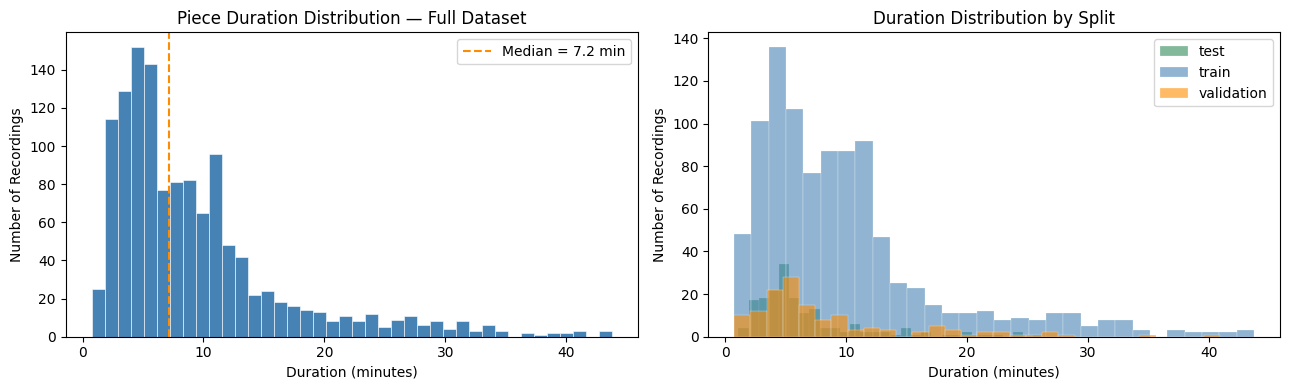

Saved: eda_duration.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── All splits ────────────────────────────────────────────────────────────────
axes[0].hist(df["duration"] / 60, bins=40, color="steelblue",
             edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Number of Recordings")
axes[0].set_title("Piece Duration Distribution — Full Dataset")
axes[0].axvline(df["duration"].median() / 60, color="darkorange",
                linestyle="--", linewidth=1.5, label=f"Median = {df['duration'].median()/60:.1f} min")
axes[0].legend()

# ── Per split ─────────────────────────────────────────────────────────────────
colors = {"train": "steelblue", "validation": "darkorange", "test": "seagreen"}
for split, grp in df.groupby("split"):
    axes[1].hist(grp["duration"] / 60, bins=30, alpha=0.6,
                 label=split, color=colors[split], edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Number of Recordings")
axes[1].set_title("Duration Distribution by Split")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/eda_duration.png", dpi=150)
plt.show()
print("Saved: eda_duration.png")

=== Note Count Stats (sample of 200 files) ===
  Min    : 872
  Max    : 18,833
  Mean   : 5,116
  Median : 4,191


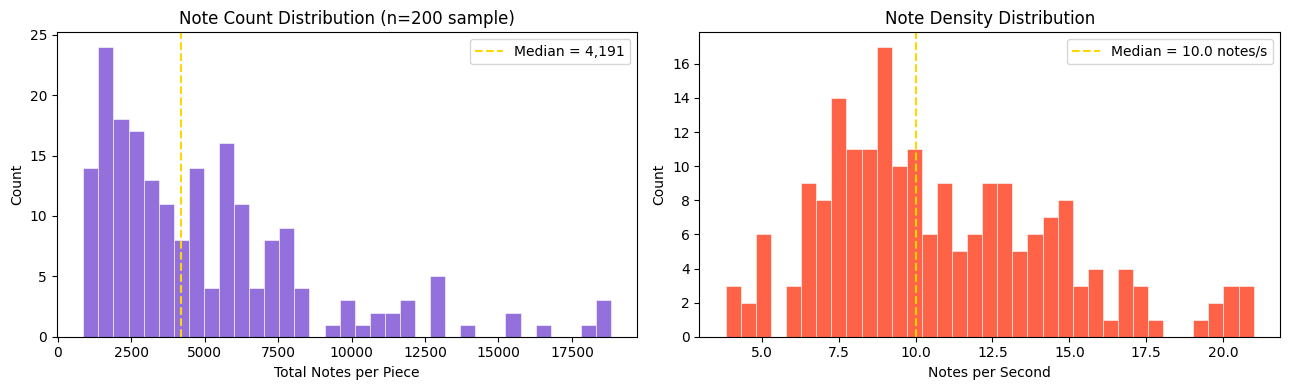

Saved: eda_note_counts.png


In [ ]:
# Sample up to 200 files to keep runtime short
sample_rows = df.sample(min(200, len(df)), random_state=CONFIG["seed"])

note_counts = []
durations_check = []

for _, row in sample_rows.iterrows():
    path = Path(CONFIG["maestro_root"]) / row["midi_filename"]
    try:
        pm = pretty_midi.PrettyMIDI(str(path))
        notes = sum(len(inst.notes) for inst in pm.instruments)
        note_counts.append(notes)
        durations_check.append(pm.get_end_time())
    except Exception as e:
        print(f"  Skip {path.name}: {e}")

note_counts      = np.array(note_counts)
durations_check  = np.array(durations_check)

print("=== Note Count Stats (sample of 200 files) ===")
print(f"  Min    : {note_counts.min():,}")
print(f"  Max    : {note_counts.max():,}")
print(f"  Mean   : {note_counts.mean():,.0f}")
print(f"  Median : {np.median(note_counts):,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(note_counts, bins=35, color="mediumpurple",
             edgecolor="white", linewidth=0.4)
axes[0].axvline(np.median(note_counts), color="gold", linestyle="--",
                linewidth=1.5, label=f"Median = {np.median(note_counts):,.0f}")
axes[0].set_xlabel("Total Notes per Piece")
axes[0].set_ylabel("Count")
axes[0].set_title("Note Count Distribution (n=200 sample)")
axes[0].legend()

# Notes per second (density)
density = note_counts / np.maximum(durations_check, 1)
axes[1].hist(density, bins=35, color="tomato",
             edgecolor="white", linewidth=0.4)
axes[1].axvline(np.median(density), color="gold", linestyle="--",
                linewidth=1.5, label=f"Median = {np.median(density):.1f} notes/s")
axes[1].set_xlabel("Notes per Second")
axes[1].set_ylabel("Count")
axes[1].set_title("Note Density Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/eda_note_counts.png", dpi=150)
plt.show()
print("Saved: eda_note_counts.png")

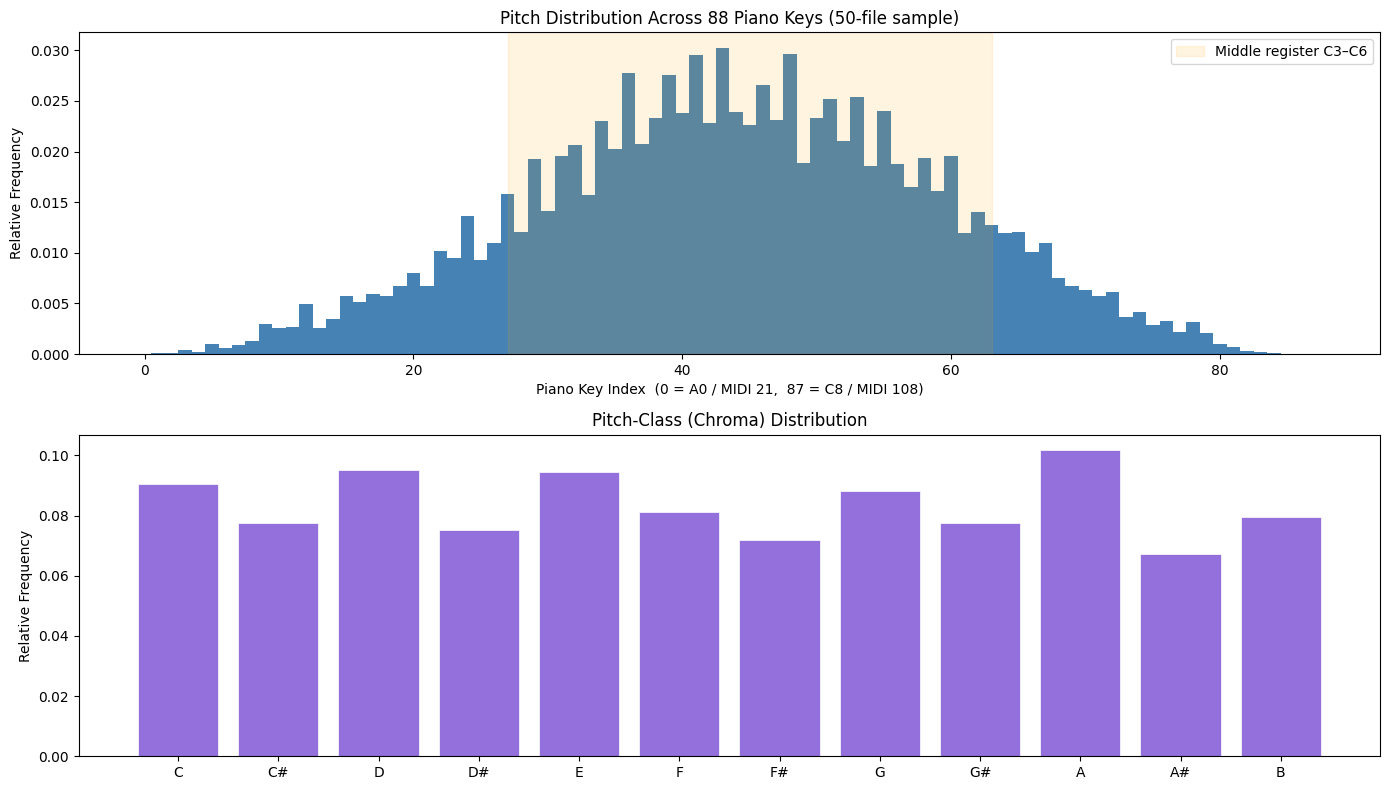

Saved: eda_pitch.png


In [ ]:
# Sample 50 files for pitch analysis
pitch_sample = df[df["split"] == "train"].sample(50, random_state=CONFIG["seed"])

pitch_counts    = np.zeros(88)         # full piano range (MIDI 21–108)
pitchclass_counts = np.zeros(12)       # C, C#, D, ... B

for _, row in pitch_sample.iterrows():
    path = Path(CONFIG["maestro_root"]) / row["midi_filename"]
    try:
        pm = pretty_midi.PrettyMIDI(str(path))
        for inst in pm.instruments:
            for note in inst.notes:
                if 21 <= note.pitch <= 108:
                    pitch_counts[note.pitch - 21] += 1
                    pitchclass_counts[note.pitch % 12] += 1
    except:
        pass

pitch_counts      /= pitch_counts.sum()
pitchclass_counts /= pitchclass_counts.sum()

note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full 88-key pitch histogram
x88 = np.arange(88)
axes[0].bar(x88, pitch_counts, color="steelblue", width=1.0, edgecolor="none")
axes[0].set_xlabel("Piano Key Index  (0 = A0 / MIDI 21,  87 = C8 / MIDI 108)")
axes[0].set_ylabel("Relative Frequency")
axes[0].set_title("Pitch Distribution Across 88 Piano Keys (50-file sample)")

# Shade the middle register C3–C6 (MIDI 48–84  →  indices 27–63)
axes[0].axvspan(27, 63, alpha=0.12, color="orange", label="Middle register C3–C6")
axes[0].legend()

# Pitch-class (chroma) histogram
axes[1].bar(np.arange(12), pitchclass_counts, color="mediumpurple",
            edgecolor="white", linewidth=0.5)
axes[1].set_xticks(np.arange(12))
axes[1].set_xticklabels(note_names)
axes[1].set_ylabel("Relative Frequency")
axes[1].set_title("Pitch-Class (Chroma) Distribution")

plt.tight_layout()
plt.savefig("/kaggle/working/eda_pitch.png", dpi=150)
plt.show()
print("Saved: eda_pitch.png")

=== Velocity Stats ===
  Min    : 1
  Max    : 126
  Mean   : 62.6
  Median : 63.0
  Std    : 19.8


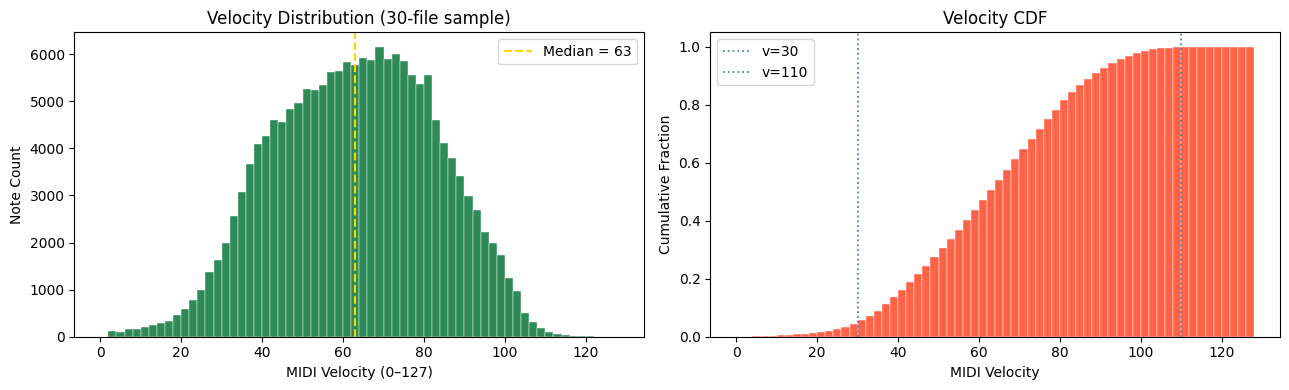

Saved: eda_velocity.png


In [ ]:
velocity_sample = df[df["split"] == "train"].sample(30, random_state=CONFIG["seed"])

all_velocities = []
for _, row in velocity_sample.iterrows():
    path = Path(CONFIG["maestro_root"]) / row["midi_filename"]
    try:
        pm = pretty_midi.PrettyMIDI(str(path))
        for inst in pm.instruments:
            for note in inst.notes:
                all_velocities.append(note.velocity)
    except:
        pass

all_velocities = np.array(all_velocities)

print("=== Velocity Stats ===")
print(f"  Min    : {all_velocities.min()}")
print(f"  Max    : {all_velocities.max()}")
print(f"  Mean   : {all_velocities.mean():.1f}")
print(f"  Median : {np.median(all_velocities):.1f}")
print(f"  Std    : {all_velocities.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(all_velocities, bins=64, range=(0, 128),
             color="seagreen", edgecolor="white", linewidth=0.3)
axes[0].axvline(np.median(all_velocities), color="gold", linestyle="--",
                linewidth=1.5, label=f"Median = {np.median(all_velocities):.0f}")
axes[0].set_xlabel("MIDI Velocity (0–127)")
axes[0].set_ylabel("Note Count")
axes[0].set_title("Velocity Distribution (30-file sample)")
axes[0].legend()

# Cumulative distribution
axes[1].hist(all_velocities, bins=64, range=(0, 128), cumulative=True,
             density=True, color="tomato", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("MIDI Velocity")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].set_title("Velocity CDF")
axes[1].axvline(30,  color="steelblue", linestyle=":", linewidth=1.3, label="v=30")
axes[1].axvline(110, color="steelblue", linestyle=":", linewidth=1.3, label="v=110")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/eda_velocity.png", dpi=150)
plt.show()
print("Saved: eda_velocity.png")

=== Piano-Roll Sparsity (10-file sample) ===
  Mean sparsity  : 94.4% zeros
  Mean active    : 5.63% ones
  Min sparsity   : 91.6%
  Max sparsity   : 97.5%

  ⚠  This extreme imbalance is why MSE/plain-BCE fails.
  ✓  Focal Loss + sparse-window filtering addresses this.


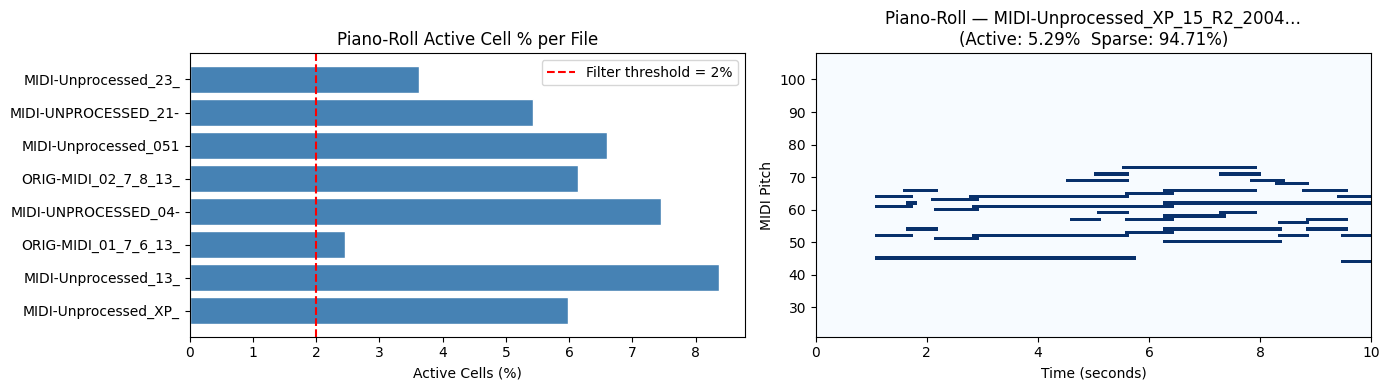

Saved: eda_sparsity.png


In [ ]:
# Sparsity is the root cause of training instability — always check this
sparsity_sample = df[df["split"] == "train"].sample(10, random_state=CONFIG["seed"])

sparsity_values = []
active_ratios_per_file = {}

for _, row in sparsity_sample.iterrows():
    path = Path(CONFIG["maestro_root"]) / row["midi_filename"]
    try:
        pm   = pretty_midi.PrettyMIDI(str(path))
        roll = pm.get_piano_roll(fs=CONFIG["fs"])   # (128, T)
        roll = roll[21:109, :]                       # (88, T)
        binary = (roll > 0).astype(np.float32)
        sparsity = 1.0 - binary.mean()              # fraction of zeros
        sparsity_values.append(sparsity)
        active_ratios_per_file[Path(row["midi_filename"]).stem[:20]] = 1.0 - sparsity
    except:
        pass

print("=== Piano-Roll Sparsity (10-file sample) ===")
print(f"  Mean sparsity  : {np.mean(sparsity_values)*100:.1f}% zeros")
print(f"  Mean active    : {(1 - np.mean(sparsity_values))*100:.2f}% ones")
print(f"  Min sparsity   : {np.min(sparsity_values)*100:.1f}%")
print(f"  Max sparsity   : {np.max(sparsity_values)*100:.1f}%")
print()
print("  ⚠  This extreme imbalance is why MSE/plain-BCE fails.")
print("  ✓  Focal Loss + sparse-window filtering addresses this.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of active cell ratio per file
files  = list(active_ratios_per_file.keys())
ratios = list(active_ratios_per_file.values())
axes[0].barh(files, [r * 100 for r in ratios], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Active Cells (%)")
axes[0].set_title("Piano-Roll Active Cell % per File")
axes[0].axvline(CONFIG["min_active"] * 100, color="red", linestyle="--",
                linewidth=1.5, label=f"Filter threshold = {CONFIG['min_active']*100:.0f}%")
axes[0].legend()

# Visualize one piano-roll (first 10 seconds = 160 frames at fs=16)
sample_path = Path(CONFIG["maestro_root"]) / sparsity_sample.iloc[0]["midi_filename"]
pm_viz  = pretty_midi.PrettyMIDI(str(sample_path))
roll_viz = pm_viz.get_piano_roll(fs=CONFIG["fs"])[21:109, :160]  # (88, 160)
roll_viz = (roll_viz > 0).astype(np.float32)

axes[1].imshow(roll_viz, aspect="auto", origin="lower",
               cmap="Blues", interpolation="nearest",
               extent=[0, 160/CONFIG["fs"], 21, 108])
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("MIDI Pitch")
axes[1].set_title(f"Piano-Roll — {sample_path.stem[:30]}…\n"
                  f"(Active: {roll_viz.mean()*100:.2f}%  Sparse: {(1-roll_viz.mean())*100:.2f}%)")

plt.tight_layout()
plt.savefig("/kaggle/working/eda_sparsity.png", dpi=150)
plt.show()
print("Saved: eda_sparsity.png")

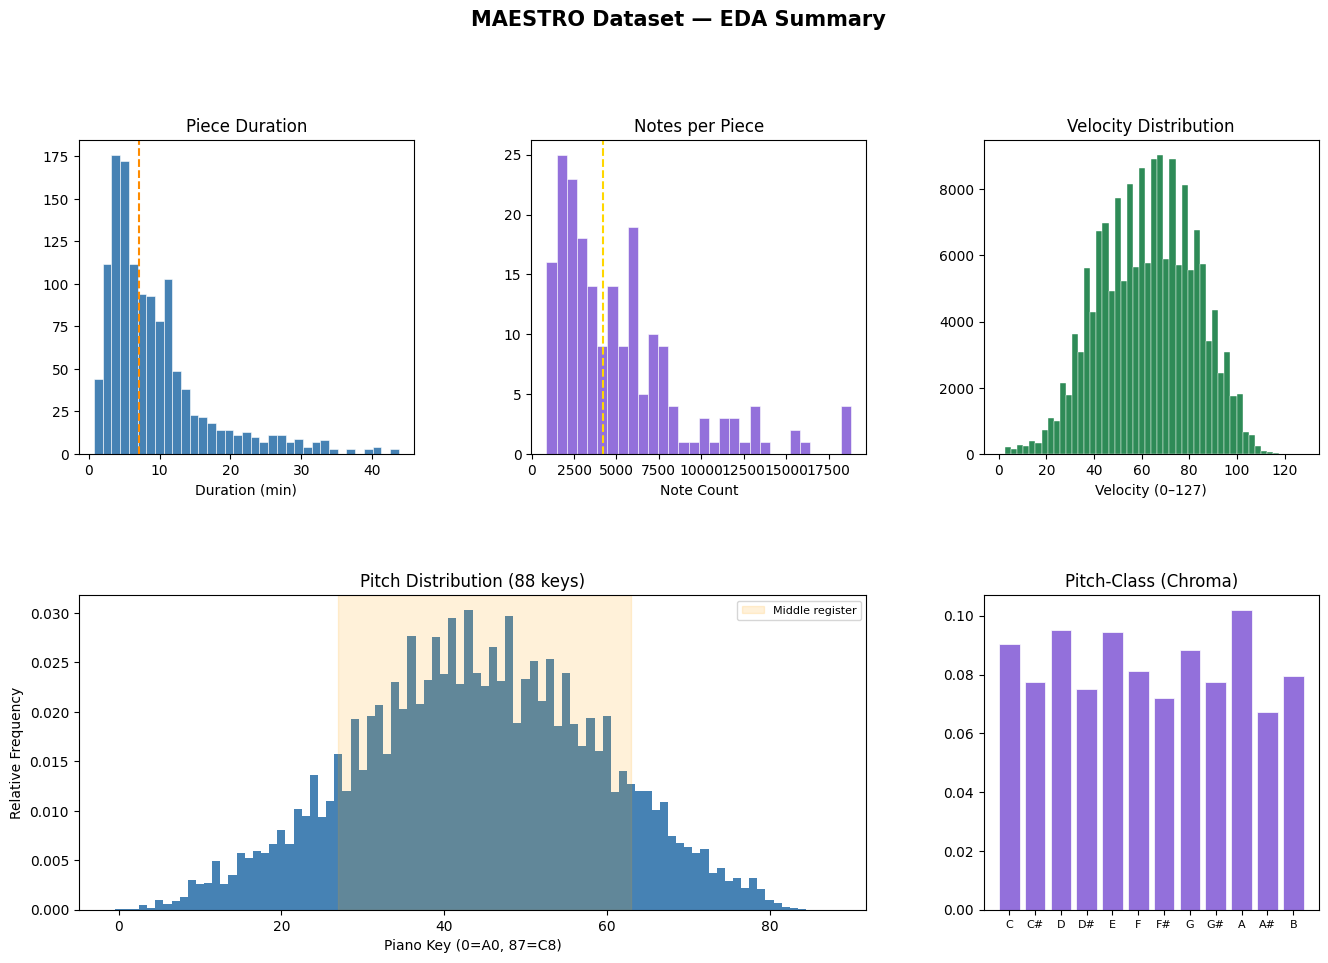

Saved: eda_dashboard.png


In [ ]:
# Consolidated single-image summary for the report
fig = plt.figure(figsize=(16, 10))
fig.suptitle("MAESTRO Dataset — EDA Summary", fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Duration
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["duration"] / 60, bins=35, color="steelblue", edgecolor="white", linewidth=0.4)
ax1.axvline(df["duration"].median() / 60, color="darkorange", linestyle="--", linewidth=1.5)
ax1.set_xlabel("Duration (min)")
ax1.set_title("Piece Duration")

# 2. Note count
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(note_counts, bins=30, color="mediumpurple", edgecolor="white", linewidth=0.4)
ax2.axvline(np.median(note_counts), color="gold", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Note Count")
ax2.set_title("Notes per Piece")

# 3. Velocity
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(all_velocities, bins=50, range=(0, 128),
         color="seagreen", edgecolor="white", linewidth=0.3)
ax3.set_xlabel("Velocity (0–127)")
ax3.set_title("Velocity Distribution")

# 4. Full pitch histogram
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.bar(np.arange(88), pitch_counts, color="steelblue", width=1.0, edgecolor="none")
ax4.axvspan(27, 63, alpha=0.15, color="orange", label="Middle register")
ax4.set_xlabel("Piano Key (0=A0, 87=C8)")
ax4.set_ylabel("Relative Frequency")
ax4.set_title("Pitch Distribution (88 keys)")
ax4.legend(fontsize=8)

# 5. Pitch class
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(np.arange(12), pitchclass_counts, color="mediumpurple",
        edgecolor="white", linewidth=0.5)
ax5.set_xticks(np.arange(12))
ax5.set_xticklabels(note_names, fontsize=8)
ax5.set_title("Pitch-Class (Chroma)")

plt.savefig("/kaggle/working/eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_dashboard.png")

# TASK 1 DATA LOADING

In [ ]:
class PianoRollDataset(Dataset):
    def __init__(self, array):
        # array: (N, T, 88) float32
        self.data = torch.tensor(array, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]   # (T, 88)


train_ds = PianoRollDataset(train_arr)
val_ds   = PianoRollDataset(val_arr)
test_ds  = PianoRollDataset(test_arr)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches per epoch  →  train: {len(train_loader)}  val: {len(val_loader)}")

Batches per epoch  →  train: 980  val: 124


# LOSS DEFINE

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for binary classification on imbalanced piano-rolls.
    Expects raw logits; applies sigmoid internally (numerically stable).
    gamma: focusing parameter — suppresses easy (silent) cell gradients.
    pos_weight: extra weight for active (note) cells.
    """
    def __init__(self, gamma=2.0, pos_weight=20.0):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        # logits, targets: (B, T, 88)
        probs  = torch.sigmoid(logits)
        bce    = nn.functional.binary_cross_entropy_with_logits(
                     logits, targets, reduction="none")

        # pt = probability of the correct class
        pt     = torch.where(targets == 1, probs, 1 - probs)
        focal  = ((1 - pt) ** self.gamma) * bce

        # extra weight on positive (note) cells
        weight = torch.where(targets == 1,
                              torch.full_like(targets, self.pos_weight),
                              torch.ones_like(targets))
        loss   = (focal * weight).mean()
        return loss

# **MODEL**

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64,
                 num_layers=2, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: (B, T, 88)
        _, (h_n, _) = self.lstm(x)
        # h_n: (num_layers, B, hidden_dim)
        # Use the last layer's hidden state at the final time step
        z = self.fc(h_n[-1])          # (B, latent_dim)
        return z


class Decoder(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=256, output_dim=88,
                 num_layers=2, dropout=0.25, seq_len=128):
        super().__init__()
        self.seq_len    = seq_len
        self.input_proj = nn.Linear(latent_dim, hidden_dim)
        # Input at each time step = hidden_dim (projected z)
        self.lstm       = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.output_fc  = nn.Linear(hidden_dim, output_dim)
        # NO sigmoid here — raw logits for BCEWithLogits / FocalLoss

    def forward(self, z):
        # z: (B, latent_dim)
        proj = self.input_proj(z)                  # (B, hidden_dim)
        # Repeat z across all time steps so the decoder can "see" z at every step
        inp  = proj.unsqueeze(1).repeat(1, self.seq_len, 1)   # (B, T, hidden_dim)
        out, _ = self.lstm(inp)                    # (B, T, hidden_dim)
        logits  = self.output_fc(out)              # (B, T, 88)  — raw logits
        return logits


class LSTMAutoencoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = Encoder(input_dim=88,
                                hidden_dim=cfg["hidden_dim"],
                                latent_dim=cfg["latent_dim"],
                                num_layers=cfg["num_layers"],
                                dropout=cfg["dropout"])
        self.decoder = Decoder(latent_dim=cfg["latent_dim"],
                                hidden_dim=cfg["hidden_dim"],
                                output_dim=88,
                                num_layers=cfg["num_layers"],
                                dropout=cfg["dropout"],
                                seq_len=cfg["window_len"])

    def forward(self, x):
        z      = self.encoder(x)
        logits = self.decoder(z)
        return logits, z


model = LSTMAutoencoder(CONFIG).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 1,989,016
LSTMAutoencoder(
  (encoder): Encoder(
    (lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.25)
    (fc): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (input_proj): Linear(in_features=64, out_features=256, bias=True)
    (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.25)
    (output_fc): Linear(in_features=256, out_features=88, bias=True)
  )
)


In [ ]:
criterion = FocalLoss(gamma=2.0, pos_weight=CONFIG["pos_weight_val"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=5)

train_losses, val_losses = [], []
best_val_loss = float("inf")

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for batch in loader:
            batch = batch.to(DEVICE)               # (B, T, 88)
            logits, _ = model(batch)
            loss = criterion(logits, batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)


print("Starting training...")
for epoch in range(1, CONFIG["epochs"] + 1):
    t_loss = run_epoch(train_loader, training=True)
    v_loss = run_epoch(val_loader,   training=False)

    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(v_loss)
    new_lr  = optimizer.param_groups[0]["lr"]

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(),
                   os.path.join(CONFIG["model_dir"], "best_model.pt"))

    if epoch % 5 == 0 or epoch == 1:
        lr_str = f"  ⬇ LR→{new_lr:.2e}" if new_lr != prev_lr else ""
        print(f"Epoch {epoch:3d}/{CONFIG['epochs']}  "
              f"Train Loss: {t_loss:.4f}  Val Loss: {v_loss:.4f}{lr_str}")

print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")

Starting training...
Epoch   1/50  Train Loss: 0.2724  Val Loss: 0.2434
Epoch   5/50  Train Loss: 0.1920  Val Loss: 0.1899
Epoch  10/50  Train Loss: 0.1693  Val Loss: 0.1739
Epoch  15/50  Train Loss: 0.1506  Val Loss: 0.1619
Epoch  20/50  Train Loss: 0.1321  Val Loss: 0.1466
Epoch  25/50  Train Loss: 0.1179  Val Loss: 0.1343
Epoch  30/50  Train Loss: 0.1065  Val Loss: 0.1249
Epoch  35/50  Train Loss: 0.0979  Val Loss: 0.1187
Epoch  40/50  Train Loss: 0.0917  Val Loss: 0.1142
Epoch  45/50  Train Loss: 0.0866  Val Loss: 0.1091
Epoch  50/50  Train Loss: 0.0829  Val Loss: 0.1070

Training complete. Best Val Loss: 0.1066


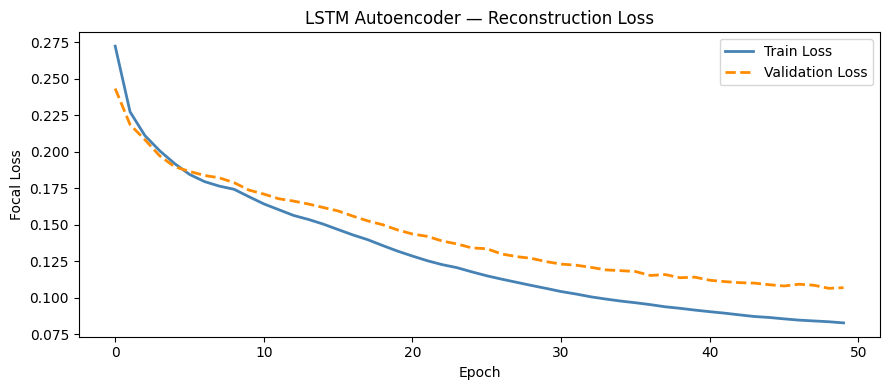

Loss curve saved.


In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label="Train Loss",      color="steelblue",  linewidth=2)
plt.plot(val_losses,   label="Validation Loss", color="darkorange",
         linewidth=2, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Focal Loss")
plt.title("LSTM Autoencoder — Reconstruction Loss")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved.")

In [ ]:
def piano_roll_to_midi(binary_roll, fs, velocity=80, program=0):
    """
    Convert a (T, 88) binary array to a PrettyMIDI object.
    Each active cell → a note of the corresponding pitch.
    """
    pm         = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=program)
    frame_dur  = 1.0 / fs

    for pitch_idx in range(88):
        midi_pitch = pitch_idx + 21    # piano range: 21–108
        col        = binary_roll[:, pitch_idx]
        # find contiguous ON segments
        in_note    = False
        note_start = 0.0

        for t, val in enumerate(col):
            if val == 1 and not in_note:
                note_start = t * frame_dur
                in_note    = True
            elif val == 0 and in_note:
                note_end = t * frame_dur
                if note_end - note_start >= frame_dur:   # at least 1 frame long
                    instrument.notes.append(
                        pretty_midi.Note(velocity=velocity,
                                         pitch=midi_pitch,
                                         start=note_start,
                                         end=note_end))
                in_note = False

        # close any note still open at the end
        if in_note:
            note_end = len(col) * frame_dur
            if note_end - note_start >= frame_dur:
                instrument.notes.append(
                    pretty_midi.Note(velocity=velocity,
                                     pitch=midi_pitch,
                                     start=note_start,
                                     end=note_end))

    pm.instruments.append(instrument)
    return pm


def verify_midi(pm):
    """Return True if the MIDI passes basic quality checks."""
    all_notes = [n for inst in pm.instruments for n in inst.notes]
    return len(all_notes) >= 50 and pm.get_end_time() >= 5.0


# Load best checkpoint
model.load_state_dict(torch.load(
    os.path.join(CONFIG["model_dir"], "best_model.pt"), map_location=DEVICE))
model.eval()

generated = 0
attempts  = 0
print("Generating MIDI samples...")

while generated < 5 and attempts < 50:
    attempts += 1
    with torch.no_grad():
        z      = torch.randn(1, CONFIG["latent_dim"]).to(DEVICE)
        logits = model.decoder(z)                        # (1, T, 88)
        probs  = torch.sigmoid(logits).squeeze(0)        # (T, 88)
        binary = (probs > CONFIG["gen_threshold"]).cpu().numpy().astype(np.float32)

    pm = piano_roll_to_midi(binary, fs=CONFIG["fs"])

    if verify_midi(pm):
        out_path = os.path.join(CONFIG["midi_out_dir"], f"sample_{generated + 1}.mid")
        pm.write(out_path)
        note_count = sum(len(inst.notes) for inst in pm.instruments)
        print(f"  Sample {generated + 1}: {note_count} notes, "
              f"{pm.get_end_time():.1f}s  → {out_path}")
        generated += 1
    else:
        print(f"  Attempt {attempts}: failed quality check — regenerating")

print(f"\nDone. {generated}/5 samples generated in {attempts} attempts.")

Generating MIDI samples...
  Sample 1: 100 notes, 8.0s  → /kaggle/working/generated_midi/sample_1.mid
  Attempt 2: failed quality check — regenerating
  Attempt 3: failed quality check — regenerating
  Attempt 4: failed quality check — regenerating
  Sample 2: 97 notes, 8.0s  → /kaggle/working/generated_midi/sample_2.mid
  Sample 3: 101 notes, 8.0s  → /kaggle/working/generated_midi/sample_3.mid
  Sample 4: 74 notes, 8.0s  → /kaggle/working/generated_midi/sample_4.mid
  Sample 5: 168 notes, 8.0s  → /kaggle/working/generated_midi/sample_5.mid

Done. 5/5 samples generated in 8 attempts.


In [ ]:
# ── Pitch Histogram Similarity ────────────────────────────────────────────────
def pitch_histogram(midi_path):
    """Return normalized 12-bin pitch-class histogram."""
    pm    = pretty_midi.PrettyMIDI(str(midi_path))
    hist  = np.zeros(12)
    for inst in pm.instruments:
        for note in inst.notes:
            hist[note.pitch % 12] += 1
    total = hist.sum()
    return hist / total if total > 0 else hist

def pitch_histogram_similarity(gen_path, ref_path):
    """L1 distance between pitch-class histograms. 0 = identical."""
    p = pitch_histogram(ref_path)
    q = pitch_histogram(gen_path)
    return float(np.abs(p - q).sum())


# ── Rhythm Diversity ──────────────────────────────────────────────────────────
def rhythm_diversity(midi_path, quantize_ms=50):
    """Unique quantized durations / total notes."""
    pm    = pretty_midi.PrettyMIDI(str(midi_path))
    durs  = []
    for inst in pm.instruments:
        for note in inst.notes:
            d_ms  = (note.end - note.start) * 1000
            d_q   = round(d_ms / quantize_ms) * quantize_ms
            durs.append(d_q)
    if not durs:
        return 0.0
    return len(set(durs)) / len(durs)


# ── Repetition Ratio ──────────────────────────────────────────────────────────
def repetition_ratio(midi_path, n=2):
    """Fraction of length-n pitch n-grams that appear more than once."""
    pm     = pretty_midi.PrettyMIDI(str(midi_path))
    notes  = sorted(
        [note for inst in pm.instruments for note in inst.notes],
        key=lambda x: x.start)
    pitches = [note.pitch for note in notes]

    if len(pitches) < n:
        return 0.0

    ngrams = [tuple(pitches[i:i+n]) for i in range(len(pitches) - n + 1)]
    counts = {}
    for g in ngrams:
        counts[g] = counts.get(g, 0) + 1

    repeated = sum(1 for c in counts.values() if c > 1)
    return repeated / len(ngrams)


# ── Run metrics on all 5 generated samples ───────────────────────────────────
gen_files = sorted(Path(CONFIG["midi_out_dir"]).glob("sample_*.mid"))
# Pick a random training file as reference
df_meta   = pd.read_csv(CONFIG["maestro_csv"])
ref_row   = df_meta[df_meta["split"] == "test"].iloc[0]
ref_path  = Path(CONFIG["maestro_root"]) / ref_row["midi_filename"]

print(f"Reference file: {ref_path.name}\n")
print(f"{'File':<20} {'PitchSim':>10} {'RhythmDiv':>12} {'RepRatio':>10}")
print("-" * 55)

for gf in gen_files:
    ps = pitch_histogram_similarity(gf, ref_path)
    rd = rhythm_diversity(gf)
    rr = repetition_ratio(gf)
    print(f"{gf.name:<20} {ps:>10.4f} {rd:>12.4f} {rr:>10.4f}")

Reference file: MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi

File                   PitchSim    RhythmDiv   RepRatio
-------------------------------------------------------
sample_1.mid             0.4804       0.4100     0.0101
sample_2.mid             0.6980       0.4330     0.0208
sample_3.mid             0.5484       0.4950     0.0000
sample_4.mid             0.3813       0.2297     0.0000
sample_5.mid             1.0258       0.1607     0.0479


# TASK 3

In [ ]:
!pip install miditok --quiet

from miditok import REMI, TokenizerConfig
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os

CONFIG_T3 = {
    "maestro_csv"  : "/kaggle/input/datasets/jihadjbjjuihhih/maestro-v3-midi/maestro-v3-midi/maestro-v3.0.0.csv",
    "maestro_root" : "/kaggle/input/datasets/jihadjbjjuihhih/maestro-v3-midi/maestro-v3-midi",

    "save_dir"      : "/kaggle/working/tokens/",
    "model_dir"     : "/kaggle/working/models_t3/",
    "midi_out_dir"  : "/kaggle/working/generated_t3/",

    # Tokenizer
    "velocity_bins" : 32,

    # Model
    "d_model"       : 256,
    "n_heads"       : 8,
    "n_layers"      : 6,
    "d_ff"          : 1024,
    "dropout"       : 0.1,
    "max_seq_len"   : 512,

    # Training
    "batch_size"    : 32,
    "lr"            : 3e-4,
    "epochs"        : 50,
    "grad_clip"     : 1.0,
    "seed"          : 42,

    # Generation
    "gen_length"    : 512,
    "temperature"   : 1.0,
    "top_k"         : 20,
}

os.makedirs(CONFIG_T3["save_dir"],   exist_ok=True)
os.makedirs(CONFIG_T3["model_dir"],  exist_ok=True)
os.makedirs(CONFIG_T3["midi_out_dir"], exist_ok=True)

torch.manual_seed(CONFIG_T3["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# Build REMI tokenizer
tokenizer_config = TokenizerConfig(
    num_velocities=CONFIG_T3["velocity_bins"],
    use_chords=False,
    use_programs=False,
)
tokenizer = REMI(tokenizer_config)

def tokenize_split(csv_path, root, split_name, tokenizer, save_dir, max_seq_len):
    save_path = Path(save_dir) / f"{split_name}_tokens.pt"
    if save_path.exists():
        print(f"  Loading cached {split_name} tokens")
        return torch.load(str(save_path))

    df   = pd.read_csv(csv_path)
    rows = df[df["split"] == split_name]
    all_sequences = []

    for _, row in rows.iterrows():
        path = Path(root) / row["midi_filename"]
        try:
            tokens = tokenizer(path)[0].ids          # flat list of int IDs
            # Chunk into non-overlapping windows of max_seq_len + 1
            for start in range(0, len(tokens) - max_seq_len, max_seq_len):
                chunk = tokens[start : start + max_seq_len + 1]
                if len(chunk) == max_seq_len + 1:
                    all_sequences.append(chunk)
        except Exception as e:
            print(f"  Skip {path.name}: {e}")

    tensor = torch.tensor(all_sequences, dtype=torch.long)  # (N, max_seq_len+1)
    torch.save(tensor, str(save_path))
    print(f"  {split_name}: {tensor.shape[0]} sequences saved")
    return tensor


print("Tokenizing dataset...")
train_tokens = tokenize_split(CONFIG_T3["maestro_csv"], CONFIG_T3["maestro_root"],
                               "train",      tokenizer, CONFIG_T3["save_dir"],
                               CONFIG_T3["max_seq_len"])
val_tokens   = tokenize_split(CONFIG_T3["maestro_csv"], CONFIG_T3["maestro_root"],
                               "validation", tokenizer, CONFIG_T3["save_dir"],
                               CONFIG_T3["max_seq_len"])
test_tokens  = tokenize_split(CONFIG_T3["maestro_csv"], CONFIG_T3["maestro_root"],
                               "test",       tokenizer, CONFIG_T3["save_dir"],
                               CONFIG_T3["max_seq_len"])

VOCAB_SIZE = tokenizer.vocab_size
print(f"\nVocab size: {VOCAB_SIZE}")
print(f"Splits  →  train: {len(train_tokens)}  val: {len(val_tokens)}  test: {len(test_tokens)}")

Tokenizing dataset...
  train: 39757 sequences saved
  validation: 4482 sequences saved
  test: 5156 sequences saved

Vocab size: 284
Splits  →  train: 39757  val: 4482  test: 5156


In [ ]:
class TokenDataset(Dataset):
    def __init__(self, tensor):
        self.data = tensor   # (N, seq_len+1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq = self.data[idx]
        x   = seq[:-1]   # input:  tokens 0 … T-1
        y   = seq[1:]    # target: tokens 1 … T
        return x, y


train_ds = TokenDataset(train_tokens)
val_ds   = TokenDataset(val_tokens)
test_ds  = TokenDataset(test_tokens)

train_loader = DataLoader(train_ds, batch_size=CONFIG_T3["batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG_T3["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG_T3["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches  →  train: {len(train_loader)}  val: {len(val_loader)}")

Batches  →  train: 1243  val: 141


In [ ]:
class MusicTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers,
                 d_ff, dropout, max_seq_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb   = nn.Embedding(max_seq_len, d_model)
        self.drop      = nn.Dropout(dropout)

        decoder_layer  = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

        self.fc_out    = nn.Linear(d_model, vocab_size)
        self.d_model   = d_model
        self.max_seq_len = max_seq_len

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        # x: (B, T)
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0)   # (1, T)

        emb = self.drop(self.token_emb(x) + self.pos_emb(positions))  # (B, T, d_model)

        # Causal mask — prevents attending to future tokens
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
                          T, device=x.device)                         # (T, T)

        # Decoder-only: memory = emb (self-attention only)
        out    = self.transformer(emb, emb, tgt_mask=causal_mask,
                                  memory_mask=causal_mask,
                                  tgt_is_causal=True,
                                  memory_is_causal=True)              # (B, T, d_model)
        logits = self.fc_out(out)                                     # (B, T, vocab_size)
        return logits


model_t3 = MusicTransformer(
    vocab_size   = VOCAB_SIZE,
    d_model      = CONFIG_T3["d_model"],
    n_heads      = CONFIG_T3["n_heads"],
    n_layers     = CONFIG_T3["n_layers"],
    d_ff         = CONFIG_T3["d_ff"],
    dropout      = CONFIG_T3["dropout"],
    max_seq_len  = CONFIG_T3["max_seq_len"],
).to(DEVICE)

total_params = sum(p.numel() for p in model_t3.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

Model parameters: 6,597,404


In [ ]:
criterion_t3 = nn.CrossEntropyLoss()
optimizer_t3 = torch.optim.Adam(model_t3.parameters(), lr=CONFIG_T3["lr"])
scheduler_t3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
                   optimizer_t3, mode="min", factor=0.5, patience=5)

train_losses_t3, val_losses_t3 = [], []
best_val_loss_t3 = float("inf")


def run_epoch_t3(loader, training=True):
    model_t3.train() if training else model_t3.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)   # (B, T)
            logits = model_t3(x)                 # (B, T, vocab_size)

            # Flatten for cross-entropy
            loss = criterion_t3(
                logits.reshape(-1, VOCAB_SIZE),
                y.reshape(-1))

            if training:
                optimizer_t3.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model_t3.parameters(), CONFIG_T3["grad_clip"])
                optimizer_t3.step()

            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    perplexity = np.exp(avg_loss)
    return avg_loss, perplexity


print("Starting Task 3 training...")
for epoch in range(1, CONFIG_T3["epochs"] + 1):
    t_loss, t_ppl = run_epoch_t3(train_loader, training=True)
    v_loss, v_ppl = run_epoch_t3(val_loader,   training=False)

    prev_lr = optimizer_t3.param_groups[0]["lr"]
    scheduler_t3.step(v_loss)
    new_lr  = optimizer_t3.param_groups[0]["lr"]

    train_losses_t3.append(t_loss)
    val_losses_t3.append(v_loss)

    if v_loss < best_val_loss_t3:
        best_val_loss_t3 = v_loss
        torch.save(model_t3.state_dict(),
                   os.path.join(CONFIG_T3["model_dir"], "best_model_t3.pt"))

    if epoch % 5 == 0 or epoch == 1:
        lr_str = f"  ⬇ LR→{new_lr:.2e}" if new_lr != prev_lr else ""
        print(f"Epoch {epoch:3d}/{CONFIG_T3['epochs']}  "
              f"Train Loss: {t_loss:.4f}  PPL: {t_ppl:.2f}  |  "
              f"Val Loss: {v_loss:.4f}  PPL: {v_ppl:.2f}{lr_str}")

print(f"\nBest Val Loss: {best_val_loss_t3:.4f}")

Starting Task 3 training...
Epoch   1/50  Train Loss: 2.7155  PPL: 15.11  |  Val Loss: 2.4418  PPL: 11.49
Epoch   5/50  Train Loss: 2.1390  PPL: 8.49  |  Val Loss: 2.1357  PPL: 8.46
Epoch  10/50  Train Loss: 1.9234  PPL: 6.84  |  Val Loss: 1.9851  PPL: 7.28
Epoch  15/50  Train Loss: 1.8351  PPL: 6.27  |  Val Loss: 1.9397  PPL: 6.96
Epoch  20/50  Train Loss: 1.7841  PPL: 5.95  |  Val Loss: 1.9198  PPL: 6.82
Epoch  25/50  Train Loss: 1.7487  PPL: 5.75  |  Val Loss: 1.9104  PPL: 6.76
Epoch  30/50  Train Loss: 1.7225  PPL: 5.60  |  Val Loss: 1.9017  PPL: 6.70
Epoch  35/50  Train Loss: 1.7022  PPL: 5.49  |  Val Loss: 1.8939  PPL: 6.65
Epoch  40/50  Train Loss: 1.6856  PPL: 5.40  |  Val Loss: 1.8935  PPL: 6.64
Epoch  45/50  Train Loss: 1.6550  PPL: 5.23  |  Val Loss: 1.8848  PPL: 6.59
Epoch  50/50  Train Loss: 1.6434  PPL: 5.17  |  Val Loss: 1.8860  PPL: 6.59

Best Val Loss: 1.8835


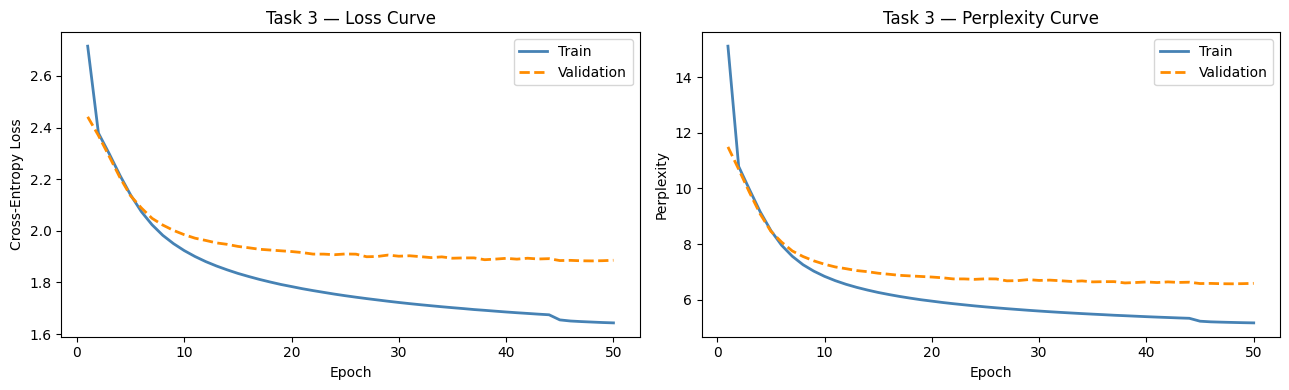

Saved: loss_curve_t3.png


In [ ]:
epochs_range = range(1, len(train_losses_t3) + 1)
train_ppls   = [np.exp(l) for l in train_losses_t3]
val_ppls     = [np.exp(l) for l in val_losses_t3]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, train_losses_t3, label="Train",      color="steelblue",  linewidth=2)
axes[0].plot(epochs_range, val_losses_t3,   label="Validation", color="darkorange", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Task 3 — Loss Curve"); axes[0].legend()

axes[1].plot(epochs_range, train_ppls, label="Train",      color="steelblue",  linewidth=2)
axes[1].plot(epochs_range, val_ppls,   label="Validation", color="darkorange", linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Task 3 — Perplexity Curve"); axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve_t3.png", dpi=150)
plt.show()
print("Saved: loss_curve_t3.png")

In [ ]:
def top_k_sample(logits, k, temperature):
    """Sample from top-k logits with temperature."""
    logits = logits / temperature
    top_vals, top_idx = torch.topk(logits, k)
    probs = torch.softmax(top_vals, dim=-1)
    chosen = torch.multinomial(probs, 1)
    return top_idx[chosen]


def generate_sequence(model, tokenizer, seed_token_id, length, temperature, top_k, device):
    model.eval()
    generated = [seed_token_id]

    with torch.no_grad():
        for _ in range(length):
            # Use last max_seq_len tokens as context
            context = generated[-CONFIG_T3["max_seq_len"]:]
            x = torch.tensor([context], dtype=torch.long).to(device)
            logits = model(x)                        # (1, T, vocab_size)
            next_logits = logits[0, -1, :]           # (vocab_size,)

            # Mask padding token (id=0) to prevent sampling it
            next_logits[0] = float("-inf")

            next_id = top_k_sample(next_logits, top_k, temperature)
            generated.append(next_id.item())

    return generated


# Load best checkpoint
model_t3.load_state_dict(torch.load(
    os.path.join(CONFIG_T3["model_dir"], "best_model_t3.pt"), map_location=DEVICE))

# Seed token — use the Bar token id
bar_token_id = tokenizer["Bar_None"]
print(f"Seed token: Bar_None (id={bar_token_id})")
print("Generating 10 compositions...\n")

for i in range(10):
    token_ids = generate_sequence(
        model_t3, tokenizer,
        seed_token_id = bar_token_id,
        length        = CONFIG_T3["gen_length"],
        temperature   = CONFIG_T3["temperature"],
        top_k         = CONFIG_T3["top_k"],
        device        = DEVICE)

    # Convert tokens → MIDI
    out_path = os.path.join(CONFIG_T3["midi_out_dir"], f"t3_sample_{i+1}.mid")
    try:
        score = tokenizer.decode([token_ids])
        score.dump_midi(out_path)
        pm_check   = pretty_midi.PrettyMIDI(out_path)
        note_count = sum(len(inst.notes) for inst in pm_check.instruments)
        print(f"  Sample {i+1}: {note_count} notes, {pm_check.get_end_time():.1f}s → {out_path}")
    except Exception as e:
        print(f"  Sample {i+1}: failed — {e}")

Seed token: Bar_None (id=4)
Generating 10 compositions...

  Sample 1: 134 notes, 12.4s → /kaggle/working/generated_t3/t3_sample_1.mid
  Sample 2: 150 notes, 7.4s → /kaggle/working/generated_t3/t3_sample_2.mid
  Sample 3: 137 notes, 11.6s → /kaggle/working/generated_t3/t3_sample_3.mid
  Sample 4: 130 notes, 27.2s → /kaggle/working/generated_t3/t3_sample_4.mid
  Sample 5: 139 notes, 9.1s → /kaggle/working/generated_t3/t3_sample_5.mid
  Sample 6: 132 notes, 9.8s → /kaggle/working/generated_t3/t3_sample_6.mid
  Sample 7: 138 notes, 11.6s → /kaggle/working/generated_t3/t3_sample_7.mid
  Sample 8: 142 notes, 11.6s → /kaggle/working/generated_t3/t3_sample_8.mid
  Sample 9: 129 notes, 16.0s → /kaggle/working/generated_t3/t3_sample_9.mid
  Sample 10: 141 notes, 7.4s → /kaggle/working/generated_t3/t3_sample_10.mid


In [ ]:
# ── Test set perplexity ───────────────────────────────────────────────────────
_, test_ppl = run_epoch_t3(test_loader, training=False)
print(f"Test Perplexity: {test_ppl:.2f}")

# ── Reuse metric functions from Task 1 on generated MIDIs ────────────────────
gen_files_t3 = sorted(Path(CONFIG_T3["midi_out_dir"]).glob("t3_sample_*.mid"))
df_meta      = pd.read_csv(CONFIG_T3["maestro_csv"])
ref_path     = Path(CONFIG_T3["maestro_root"]) / df_meta[df_meta["split"]=="test"].iloc[0]["midi_filename"]

print(f"\nReference: {ref_path.name}\n")
print(f"{'File':<22} {'PitchSim':>10} {'RhythmDiv':>12} {'RepRatio':>10}")
print("-" * 57)

for gf in gen_files_t3:
    ps = pitch_histogram_similarity(gf, ref_path)
    rd = rhythm_diversity(gf)
    rr = repetition_ratio(gf)
    print(f"{gf.name:<22} {ps:>10.4f} {rd:>12.4f} {rr:>10.4f}")

Test Perplexity: 6.03

Reference: MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi

File                     PitchSim    RhythmDiv   RepRatio
---------------------------------------------------------
t3_sample_1.mid            0.7441       0.0522     0.1579
t3_sample_10.mid           0.9106       0.0284     0.1214
t3_sample_2.mid            0.9492       0.0267     0.1879
t3_sample_3.mid            0.5884       0.0511     0.1618
t3_sample_4.mid            0.6919       0.1231     0.2016
t3_sample_5.mid            0.9763       0.0360     0.1159
t3_sample_6.mid            0.8889       0.0303     0.1374
t3_sample_7.mid            0.7827       0.0362     0.1533
t3_sample_8.mid            0.7941       0.0423     0.2057
t3_sample_9.mid            0.8900       0.1240     0.0938


# **TASK 4**

In [ ]:
CONFIG_T4 = {
    "model_dir"     : "/kaggle/working/models_t4/",
    "midi_out_dir"  : "/kaggle/working/generated_t4/",
    "survey_path"   : "/kaggle/working/survey_results.csv",

    # RL Training
    "epochs"        : 50,
    "batch_size"    : 8,       # small — each sample needs generation
    "gen_length"    : 256,
    "temperature"   : 1.0,
    "top_k"         : 20,
    "lr"            : 1e-5,    # very small for fine-tuning
    "grad_clip"     : 1.0,

    # KL penalty weight (prevents reward hacking)
    "kl_lambda"     : 0.1,

    "seed"          : 42,
}

os.makedirs(CONFIG_T4["model_dir"],   exist_ok=True)
os.makedirs(CONFIG_T4["midi_out_dir"], exist_ok=True)

torch.manual_seed(CONFIG_T4["seed"])
print("Device:", DEVICE)

Device: cuda


In [ ]:
# Policy — will be fine-tuned
policy = MusicTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = CONFIG_T3["d_model"],
    n_heads     = CONFIG_T3["n_heads"],
    n_layers    = CONFIG_T3["n_layers"],
    d_ff        = CONFIG_T3["d_ff"],
    dropout     = CONFIG_T3["dropout"],
    max_seq_len = CONFIG_T3["max_seq_len"],
).to(DEVICE)

policy.load_state_dict(torch.load(
    os.path.join(CONFIG_T3["model_dir"], "best_model_t3.pt"), map_location=DEVICE))

# Reference model — frozen, used for KL penalty
ref_model = MusicTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = CONFIG_T3["d_model"],
    n_heads     = CONFIG_T3["n_heads"],
    n_layers    = CONFIG_T3["n_layers"],
    d_ff        = CONFIG_T3["d_ff"],
    dropout     = CONFIG_T3["dropout"],
    max_seq_len = CONFIG_T3["max_seq_len"],
).to(DEVICE)

ref_model.load_state_dict(torch.load(
    os.path.join(CONFIG_T3["model_dir"], "best_model_t3.pt"), map_location=DEVICE))

# Freeze reference model
for p in ref_model.parameters():
    p.requires_grad = False

ref_model.eval()
print("Policy and reference model loaded.")

Policy and reference model loaded.


In [ ]:
class RewardModel(nn.Module):
    """
    Small MLP that predicts human score (1-5) from 4 musical features:
    pitch_sim, rhythm_diversity, repetition_ratio, note_density
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()   # output in (0,1), scale to 1-5 later
        )

    def forward(self, x):
        return self.net(x).squeeze(-1) * 4 + 1   # scale to 1–5


reward_model = RewardModel().to(DEVICE)
print("Reward model created.")

Reward model created.


In [ ]:
def extract_features(midi_path, ref_path):
    """
    Returns a 4-element feature vector:
    [pitch_sim, rhythm_diversity, repetition_ratio, note_density]
    """
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        notes = sum(len(inst.notes) for inst in pm.instruments)
        duration = max(pm.get_end_time(), 1.0)

        ps = pitch_histogram_similarity(midi_path, ref_path)
        rd = rhythm_diversity(midi_path)
        rr = repetition_ratio(midi_path)
        nd = notes / duration   # notes per second

        # Normalize note density to ~0-1 range (clip at 20 notes/sec)
        nd = min(nd / 20.0, 1.0)

        # Invert pitch_sim so higher = better (sim=0 is perfect)
        ps_inv = max(0.0, 1.0 - ps / 2.0)

        return [ps_inv, rd, rr, nd]
    except:
        return [0.0, 0.0, 0.0, 0.0]

In [ ]:
# Generate 20 samples from the pretrained Task 3 model for human rating
print("Generating 20 samples for human survey...")
survey_midi_dir = "/kaggle/working/survey_midi/"
os.makedirs(survey_midi_dir, exist_ok=True)

bar_token_id = tokenizer["Bar_None"]

for i in range(20):
    token_ids = generate_sequence(
        policy, tokenizer,
        seed_token_id = bar_token_id,
        length        = CONFIG_T4["gen_length"],
        temperature   = CONFIG_T4["temperature"],
        top_k         = CONFIG_T4["top_k"],
        device        = DEVICE)
    out_path = os.path.join(survey_midi_dir, f"survey_{i+1}.mid")
    try:
        score = tokenizer.decode([token_ids])
        score.dump_midi(out_path)
        pm_check   = pretty_midi.PrettyMIDI(out_path)
        note_count = sum(len(inst.notes) for inst in pm_check.instruments)
        print(f"  Sample {i+1}: {note_count} notes, {pm_check.get_end_time():.1f}s → {out_path}")
    except Exception as e:
        print(f"  Sample {i+1}: failed — {e}")

# Create empty survey CSV for human raters to fill
survey_files = sorted(Path(survey_midi_dir).glob("survey_*.mid"))
survey_df = pd.DataFrame({
    "filename" : [f.name for f in survey_files],
    "score"    : [0] * len(survey_files)   # raters fill this (1-5)
})
survey_df.to_csv(CONFIG_T4["survey_path"], index=False)
print(f"\nSurvey CSV saved → {CONFIG_T4['survey_path']}")
print("Fill in the 'score' column (1–5) with ratings from 10+ participants, then continue.")

Generating 20 samples for human survey...
  Sample 1: 72 notes, 5.9s → /kaggle/working/survey_midi/survey_1.mid
  Sample 2: 65 notes, 7.1s → /kaggle/working/survey_midi/survey_2.mid
  Sample 3: 62 notes, 16.6s → /kaggle/working/survey_midi/survey_3.mid
  Sample 4: 76 notes, 15.1s → /kaggle/working/survey_midi/survey_4.mid
  Sample 5: 71 notes, 8.1s → /kaggle/working/survey_midi/survey_5.mid
  Sample 6: 65 notes, 7.8s → /kaggle/working/survey_midi/survey_6.mid
  Sample 7: 61 notes, 24.4s → /kaggle/working/survey_midi/survey_7.mid
  Sample 8: 71 notes, 3.8s → /kaggle/working/survey_midi/survey_8.mid
  Sample 9: 71 notes, 6.8s → /kaggle/working/survey_midi/survey_9.mid
  Sample 10: 65 notes, 10.6s → /kaggle/working/survey_midi/survey_10.mid
  Sample 11: 67 notes, 7.2s → /kaggle/working/survey_midi/survey_11.mid
  Sample 12: 66 notes, 5.8s → /kaggle/working/survey_midi/survey_12.mid
  Sample 13: 62 notes, 17.0s → /kaggle/working/survey_midi/survey_13.mid
  Sample 14: 66 notes, 5.4s → /kagg

In [ ]:
import pandas as pd

#DATA FROM SURVEY
data = {
    "filename": [f"survey_{i+1}.mid" for i in range(20)],
    "score":    [2.9, 4.2, 3.5, 3.0, 2.7,   #  real scores
                 3.6, 3.8, 2.6, 3.1, 2.5,
                 3.4, 3.0, 3.7, 2.4, 2.0,
                 3.1, 4.0, 2.3, 2.4, 1.5]
}

df_survey = pd.DataFrame(data)
df_survey.to_csv(CONFIG_T4["survey_path"], index=False)
print("Survey CSV saved:")
print(df_survey.to_string(index=False))

Survey CSV saved:
     filename  score
 survey_1.mid    2.9
 survey_2.mid    4.2
 survey_3.mid    3.5
 survey_4.mid    3.0
 survey_5.mid    2.7
 survey_6.mid    3.6
 survey_7.mid    3.8
 survey_8.mid    2.6
 survey_9.mid    3.1
survey_10.mid    2.5
survey_11.mid    3.4
survey_12.mid    3.0
survey_13.mid    3.7
survey_14.mid    2.4
survey_15.mid    2.0
survey_16.mid    3.1
survey_17.mid    4.0
survey_18.mid    2.3
survey_19.mid    2.4
survey_20.mid    1.5


In [ ]:
# ── After filling survey CSV, run this block ─────────────────────────────────

df_survey = pd.read_csv(CONFIG_T4["survey_path"])
print(f"Survey entries: {len(df_survey)}")
print(df_survey.head())

ref_path = Path(CONFIG_T3["maestro_root"]) / \
           pd.read_csv(CONFIG_T3["maestro_csv"])[
               lambda d: d["split"]=="test"].iloc[0]["midi_filename"]

# Build feature matrix
features, scores = [], []
for _, row in df_survey.iterrows():
    midi_path = Path(survey_midi_dir) / row["filename"]
    feat = extract_features(midi_path, ref_path)
    features.append(feat)
    scores.append(row["score"])

X = torch.tensor(features, dtype=torch.float32).to(DEVICE)
y = torch.tensor(scores,   dtype=torch.float32).to(DEVICE)

# Train reward model
rm_optimizer = torch.optim.Adam(reward_model.parameters(), lr=1e-3, weight_decay=1e-4)
rm_criterion = nn.MSELoss()

print("\nTraining reward model...")
for epoch in range(200):
    reward_model.train()
    pred = reward_model(X)
    loss = rm_criterion(pred, y)
    rm_optimizer.zero_grad()
    loss.backward()
    rm_optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1}/200  Loss: {loss.item():.4f}")

torch.save(reward_model.state_dict(),
           os.path.join(CONFIG_T4["model_dir"], "reward_model.pt"))
print("Reward model saved.")

Survey entries: 20
       filename  score
0  survey_1.mid    2.9
1  survey_2.mid    4.2
2  survey_3.mid    3.5
3  survey_4.mid    3.0
4  survey_5.mid    2.7

Training reward model...
  Epoch 50/200  Loss: 4.1953
  Epoch 100/200  Loss: 0.4460
  Epoch 150/200  Loss: 0.4987
  Epoch 200/200  Loss: 0.4321
Reward model saved.


In [ ]:
policy_optimizer = torch.optim.Adam(policy.parameters(), lr=CONFIG_T4["lr"])

print("Starting REINFORCE fine-tuning...")
rl_rewards_per_epoch = []
best_rl_reward = -float("inf")

for epoch in range(1, CONFIG_T4["epochs"] + 1):
    policy.train()
    reward_model.eval()

    batch_rewards   = []
    batch_log_probs = []
    batch_kl        = []

    for idx in range(CONFIG_T4["batch_size"]):
        # 1. Generate sample
        token_ids = generate_sequence(
            policy, tokenizer,
            seed_token_id = bar_token_id,
            length        = CONFIG_T4["gen_length"],
            temperature   = CONFIG_T4["temperature"],
            top_k         = CONFIG_T4["top_k"],
            device        = DEVICE)

        # 2. Save to unique temp file and extract features
        tmp_path = f"/kaggle/working/tmp_gen_{idx}.mid"
        try:
            score = tokenizer.decode([token_ids])
            score.dump_midi(tmp_path)
            feat = extract_features(tmp_path, ref_path)
        except Exception as e:
            print(f"  Sample {idx+1} midi failed: {e}")
            feat = [0.0, 0.0, 0.0, 0.0]

        # 3. Get reward
        feat_tensor = torch.tensor([feat], dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            reward = reward_model(feat_tensor).item()

        print(f"  Sample {idx+1}: reward={reward:.3f}  feat={[round(float(f),3) for f in feat]}")

        # 4. Compute log prob and KL
        log_prob = compute_log_probs(policy, token_ids)
        kl       = compute_kl_penalty(policy, ref_model, token_ids)

        batch_rewards.append(reward)
        batch_log_probs.append(log_prob)
        batch_kl.append(kl)

    # 5. Normalize rewards
    rewards_t    = torch.tensor(batch_rewards, dtype=torch.float32)
    rewards_norm = (rewards_t - rewards_t.mean()) / (rewards_t.std() + 1e-8)

    # 6. REINFORCE loss + KL penalty
    policy_loss = torch.tensor(0.0, requires_grad=True).to(DEVICE)
    for i in range(CONFIG_T4["batch_size"]):
        policy_loss = policy_loss + (-rewards_norm[i].to(DEVICE) * batch_log_probs[i])
        policy_loss = policy_loss + (CONFIG_T4["kl_lambda"] * batch_kl[i])
    policy_loss = policy_loss / CONFIG_T4["batch_size"]

    policy_optimizer.zero_grad()
    policy_loss.backward()
    nn.utils.clip_grad_norm_(policy.parameters(), CONFIG_T4["grad_clip"])
    policy_optimizer.step()

    mean_reward = rewards_t.mean().item()
    rl_rewards_per_epoch.append(mean_reward)

    # Save best model
    if mean_reward > best_rl_reward:
        best_rl_reward = mean_reward
        torch.save(policy.state_dict(),
                   os.path.join(CONFIG_T4["model_dir"], "rl_policy_best.pt"))
        print(f"  ✓ Best model saved (reward={best_rl_reward:.4f})")

    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{CONFIG_T4['epochs']}  "
              f"Mean Reward: {mean_reward:.4f}  "
              f"Policy Loss: {policy_loss.item():.4f}")

torch.save(policy.state_dict(),
           os.path.join(CONFIG_T4["model_dir"], "rl_policy_last.pt"))
print(f"\nBest RL reward: {best_rl_reward:.4f}")
print("Training complete.")

Starting REINFORCE fine-tuning...
  Sample 1: reward=2.849  feat=[0.434, 0.029, 0.188, 0.418]
  Sample 2: reward=2.803  feat=[0.241, 0.162, 0.219, 0.354]
  Sample 3: reward=3.046  feat=[0.69, 0.103, 0.075, 0.598]
  Sample 4: reward=2.751  feat=[0.386, 0.095, 0.205, 0.643]
  Sample 5: reward=2.873  feat=[0.37, 0.114, 0.145, 0.415]
  Sample 6: reward=2.825  feat=[0.295, 0.029, 0.13, 0.315]
  Sample 7: reward=3.110  feat=[0.595, 0.154, 0.156, 0.271]
  Sample 8: reward=3.098  feat=[0.575, 0.164, 0.106, 0.331]
  ✓ Best model saved (reward=2.9193)
Epoch   1/50  Mean Reward: 2.9193  Policy Loss: 27.5194
  Sample 1: reward=3.070  feat=[0.585, 0.147, 0.149, 0.346]
  Sample 2: reward=3.233  feat=[0.677, 0.225, 0.1, 0.256]
  Sample 3: reward=3.099  feat=[0.531, 0.208, 0.141, 0.278]
  Sample 4: reward=2.774  feat=[0.435, 0.042, 0.143, 0.668]
  Sample 5: reward=3.204  feat=[0.554, 0.359, 0.19, 0.122]
  Sample 6: reward=2.973  feat=[0.427, 0.186, 0.188, 0.322]
  Sample 7: reward=3.049  feat=[0.602, 

In [ ]:
policy.load_state_dict(torch.load(
os.path.join(CONFIG_T4["model_dir"], "rl_policy.pt"), map_location=DEVICE))
policy.eval()

print("Generating 10 RL fine-tuned compositions...")
for i in range(10):
    token_ids = generate_sequence(
        policy, tokenizer,
        seed_token_id = bar_token_id,
        length        = CONFIG_T4["gen_length"],
        temperature   = CONFIG_T4["temperature"],
        top_k         = CONFIG_T4["top_k"],
        device        = DEVICE)

    out_path = os.path.join(CONFIG_T4["midi_out_dir"], f"t4_sample_{i+1}.mid")
    try:
        score = tokenizer.decode([token_ids])
        score.dump_midi(out_path)
        pm_check   = pretty_midi.PrettyMIDI(out_path)
        note_count = sum(len(inst.notes) for inst in pm_check.instruments)
        print(f"  Sample {i+1}: {note_count} notes, {pm_check.get_end_time():.1f}s → {out_path}")
    except Exception as e:
        print(f"  Sample {i+1}: failed — {e}")

Generating 10 RL fine-tuned compositions...
  Sample 1: 62 notes, 11.2s → /kaggle/working/generated_t4/t4_sample_1.mid
  Sample 2: 65 notes, 7.4s → /kaggle/working/generated_t4/t4_sample_2.mid
  Sample 3: 74 notes, 15.3s → /kaggle/working/generated_t4/t4_sample_3.mid
  Sample 4: 65 notes, 9.4s → /kaggle/working/generated_t4/t4_sample_4.mid
  Sample 5: 73 notes, 19.4s → /kaggle/working/generated_t4/t4_sample_5.mid
  Sample 6: 70 notes, 8.2s → /kaggle/working/generated_t4/t4_sample_6.mid
  Sample 7: 64 notes, 23.1s → /kaggle/working/generated_t4/t4_sample_7.mid
  Sample 8: 70 notes, 8.2s → /kaggle/working/generated_t4/t4_sample_8.mid
  Sample 9: 61 notes, 20.3s → /kaggle/working/generated_t4/t4_sample_9.mid
  Sample 10: 66 notes, 6.8s → /kaggle/working/generated_t4/t4_sample_10.mid


In [ ]:
# --- Analysis for Task 4 Files ---

t4_dir_path = Path("/content/Task4Midifiles/")
t4_dir_path.mkdir(parents=True, exist_ok=True)

t4_files = sorted(t4_dir_path.glob("t4_sample_*.mid"))

ps4, rd4, rr4 = avg_metrics(t4_files, ref_midi)

print("\n--- Aggregated Task 4 Metrics ---")
print(f"{'Model':<25} {'PitchSim↓':>10} {'RhythmDiv↑':>12} {'RepRatio':>10}")
print("=" * 72)
print(f"{'Task4 Model':<25} {ps4:>10.4f} {rd4:>12.4f} {rr4:>10.4f} ")

print("\n--- Individual Task 4 File Metrics ---")
print(f"{'Filename':<30} {'PitchSim↓':>10} {'RhythmDiv↑':>12} {'RepRatio':>10}")
print("=" * 72)

for midi_file in t4_files:
    try:
        ps = pitch_histogram_similarity(midi_file, ref_midi)
        rd = rhythm_diversity(midi_file)
        rr = repetition_ratio(midi_file)
        print(f"{midi_file.name:<30} {ps:>10.4f} {rd:>12.4f} {rr:>10.4f}")
    except Exception as e:
        print(f"{midi_file.name:<30} {'Error':>10} {'Error':>12} {'Error':>10} - {e}")


--- Aggregated Task 4 Metrics ---
Model                      PitchSim↓   RhythmDiv↑   RepRatio
Task4 Model                   1.0593       0.1552     0.1875 

--- Individual Task 4 File Metrics ---
Filename                        PitchSim↓   RhythmDiv↑   RepRatio
t4_sample_1.mid                    1.0378       0.1935     0.1967
t4_sample_10.mid                   0.9502       0.1061     0.2000
t4_sample_2.mid                    1.2003       0.0769     0.1875
t4_sample_3.mid                    0.8350       0.1486     0.1781
t4_sample_4.mid                    1.2190       0.1846     0.1250
t4_sample_5.mid                    1.0523       0.1507     0.1528
t4_sample_6.mid                    1.0166       0.0286     0.2464
t4_sample_7.mid                    0.9045       0.2188     0.2381
t4_sample_8.mid                    1.0444       0.2143     0.2174
t4_sample_9.mid                    1.3330       0.2295     0.1333


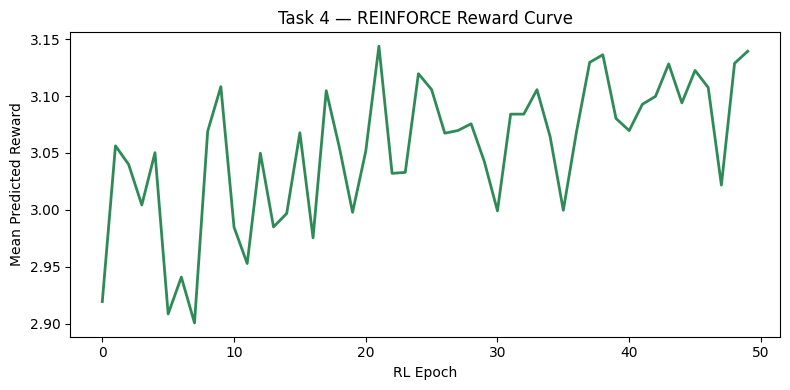


=== Before / After Comparison ===
Model                  PitchSim    RhythmDiv   RepRatio
-------------------------------------------------------
Task3 (pretrained)       0.8216       0.0550     0.1537
Task4 (RL tuned)         1.0593       0.1552     0.1875


In [ ]:
# ── Reward curve ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(rl_rewards_per_epoch, color="seagreen", linewidth=2)
plt.xlabel("RL Epoch")
plt.ylabel("Mean Predicted Reward")
plt.title("Task 4 — REINFORCE Reward Curve")
plt.tight_layout()
plt.savefig("/kaggle/working/reward_curve_t4.png", dpi=150)
plt.show()

# ── Before / After metrics comparison ────────────────────────────────────────
gen_files_t3 = sorted(Path(CONFIG_T3["midi_out_dir"]).glob("t3_sample_*.mid"))
gen_files_t4 = sorted(Path(CONFIG_T4["midi_out_dir"]).glob("t4_sample_*.mid"))

def avg_metrics(files, ref_path):
    ps_list, rd_list, rr_list = [], [], []
    for f in files:
        ps_list.append(pitch_histogram_similarity(f, ref_path))
        rd_list.append(rhythm_diversity(f))
        rr_list.append(repetition_ratio(f))
    return np.mean(ps_list), np.mean(rd_list), np.mean(rr_list)

ps3, rd3, rr3 = avg_metrics(gen_files_t3, ref_path)
ps4, rd4, rr4 = avg_metrics(gen_files_t4, ref_path)

print("\n=== Before / After Comparison ===")
print(f"{'Model':<20} {'PitchSim':>10} {'RhythmDiv':>12} {'RepRatio':>10}")
print("-" * 55)
print(f"{'Task3 (pretrained)':<20} {ps3:>10.4f} {rd3:>12.4f} {rr3:>10.4f}")
print(f"{'Task4 (RL tuned)':<20} {ps4:>10.4f} {rd4:>12.4f} {rr4:>10.4f}")

# BASELINE MODELS

In [ ]:
import pretty_midi
import numpy as np
from pathlib import Path
import os

BASELINE_DIR = "/kaggle/working/baselines/"
os.makedirs(BASELINE_DIR + "random/",  exist_ok=True)
os.makedirs(BASELINE_DIR + "markov/",  exist_ok=True)

def generate_random_midi(duration=30.0, avg_notes_per_sec=8, velocity=80,
                          durations_pool=[0.125, 0.25, 0.5, 1.0]):
    """
    Generate a MIDI file by sampling pitches and durations uniformly at random.
    duration: total length in seconds
    """
    pm         = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # Acoustic Grand Piano

    t = 0.0
    while t < duration:
        pitch    = np.random.randint(21, 109)           # piano range
        dur      = np.random.choice(durations_pool)
        end_time = min(t + dur, duration)

        instrument.notes.append(
            pretty_midi.Note(velocity=velocity,
                             pitch=pitch,
                             start=t,
                             end=end_time))
        t += dur

    pm.instruments.append(instrument)
    return pm


print("Generating 5 random baseline samples...")
for i in range(5):
    pm  = generate_random_midi(duration=30.0)
    out = BASELINE_DIR + f"random/random_{i+1}.mid"
    pm.write(out)
    notes = len(pm.instruments[0].notes)
    print(f"  random_{i+1}.mid  {notes} notes  {pm.get_end_time():.1f}s")

Generating 5 random baseline samples...
  random_1.mid  54 notes  30.0s
  random_2.mid  57 notes  30.0s
  random_3.mid  57 notes  30.0s
  random_4.mid  63 notes  30.0s
  random_5.mid  67 notes  30.0s


In [ ]:
from pathlib import Path
import numpy as np
import pretty_midi

# Define the directory for 'Random'
random_dir = Path('/content/Random/')
random_files = sorted(list(random_dir.glob('*.mid')))

def analyze_folder_individual(folder_path, files, label):
    if not files:
        print(f"No MIDI files found in {folder_path}")
        return

    # Use the first file as a reference for similarity metrics
    ref_midi = Path("/content/MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi")

    print(f"--- Individual Analysis: {label} ---")
    print(f"Directory: {folder_path}")
    print(f"Reference file: {ref_midi.name}\n")

    try:
        print(f"{'Filename':<30} {'PitchSim':>10} {'RhythmDiv':>12} {'RepRatio':>10}")
        print('-' * 70)

        for f in files:
            ps = pitch_histogram_similarity(f, ref_midi)
            rd = rhythm_diversity(f)
            rr = repetition_ratio(f)
            print(f"{f.name:<30} {ps:>10.4f} {rd:>12.4f} {rr:>10.4f}")
        print('\n')
    except NameError as e:
        print(f"Error: The analysis functions are not defined. Please run the cell containing the metric definitions first.")

# Calculate individual metrics ONLY for the random folder
analyze_folder_individual(random_dir, random_files, "Random MIDI")

--- Individual Analysis: Random MIDI ---
Directory: /content/Random
Reference file: MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi

Filename                         PitchSim    RhythmDiv   RepRatio
----------------------------------------------------------------------
random_1.mid                       0.4512       0.0667     0.0000
random_2.mid                       0.4944       0.0625     0.0000
random_3.mid                       0.4444       0.0571     0.0145
random_4.mid                       0.5157       0.0588     0.0000
random_5.mid                       0.4829       0.0690     0.0175




In [ ]:
import pandas as pd
from collections import defaultdict

def build_markov_model(csv_path, root, n_files=100):
    """
    Build:
    - pitch transition matrix  (88x88)
    - empirical duration distribution from training data
    """
    df   = pd.read_csv(csv_path)
    rows = df[df["split"] == "train"].sample(n_files, random_state=42)

    # Pitch transition counts (MIDI 21–108 → index 0–87)
    trans = np.zeros((88, 88), dtype=np.float64)

    all_durations = []

    for _, row in rows.iterrows():
        path = Path(root) / row["midi_filename"]
        try:
            pm    = pretty_midi.PrettyMIDI(str(path))
            notes = sorted(
                [n for inst in pm.instruments for n in inst.notes],
                key=lambda x: x.start)

            pitches = [n.pitch for n in notes if 21 <= n.pitch <= 108]
            durs    = [round((n.end - n.start) * 1000 / 50) * 50 / 1000
                       for n in notes if 21 <= n.pitch <= 108]

            # Count transitions
            for a, b in zip(pitches[:-1], pitches[1:]):
                trans[a - 21][b - 21] += 1

            all_durations.extend(durs)

        except Exception as e:
            print(f"  Skip: {e}")

    # Normalize rows → transition probabilities
    row_sums = trans.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1          # avoid divide-by-zero
    trans_prob = trans / row_sums

    # Duration distribution
    dur_counts = defaultdict(int)
    for d in all_durations:
        dur_counts[d] += 1
    total = sum(dur_counts.values())
    dur_dist = {k: v / total for k, v in dur_counts.items()}

    print(f"Transition matrix built from {n_files} files.")
    print(f"Unique duration values: {len(dur_dist)}")
    return trans_prob, dur_dist


trans_prob, dur_dist = build_markov_model(
    CONFIG_T3["maestro_csv"], CONFIG_T3["maestro_root"], n_files=100)

Transition matrix built from 100 files.
Unique duration values: 215


In [ ]:
def generate_markov_midi(trans_prob, dur_dist, n_notes=300, velocity=80,
                          start_pitch=60):
    """
    Generate a MIDI file by sampling from the Markov transition matrix.
    """
    pm         = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    dur_values = list(dur_dist.keys())
    dur_probs  = list(dur_dist.values())

    current_pitch = start_pitch - 21    # convert to index 0–87
    t = 0.0

    for _ in range(n_notes):
        # Sample next pitch from transition row
        row = trans_prob[current_pitch]
        if row.sum() == 0:
            next_pitch_idx = np.random.randint(0, 88)
        else:
            next_pitch_idx = np.random.choice(88, p=row)

        midi_pitch = next_pitch_idx + 21

        # Sample duration from empirical distribution
        dur = np.random.choice(dur_values, p=dur_probs)
        dur = max(dur, 0.05)    # at least 50ms

        instrument.notes.append(
            pretty_midi.Note(velocity=velocity,
                             pitch=midi_pitch,
                             start=t,
                             end=t + dur))
        t += dur
        current_pitch = next_pitch_idx

    pm.instruments.append(instrument)
    return pm


print("Generating 5 Markov baseline samples...")
start_pitches = [60, 64, 67, 55, 72]   # vary starting pitch

for i in range(5):
    pm  = generate_markov_midi(trans_prob, dur_dist,
                                n_notes=300,
                                start_pitch=start_pitches[i])
    out = BASELINE_DIR + f"markov/markov_{i+1}.mid"
    pm.write(out)
    notes = len(pm.instruments[0].notes)
    print(f"  markov_{i+1}.mid  {notes} notes  {pm.get_end_time():.1f}s")

Generating 5 Markov baseline samples...
  markov_1.mid  300 notes  62.8s
  markov_2.mid  300 notes  57.7s
  markov_3.mid  300 notes  57.0s
  markov_4.mid  300 notes  58.4s
  markov_5.mid  300 notes  43.9s


In [ ]:
from pathlib import Path
import numpy as np
import pretty_midi

# Define the directory for 'Random'
random_dir = Path('/content/markov/')
random_files = sorted(list(random_dir.glob('*.mid')))

def analyze_folder_individual(folder_path, files, label):
    if not files:
        print(f"No MIDI files found in {folder_path}")
        return

    # Use the first file as a reference for similarity metrics
    ref_midi = Path("/content/MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi")

    print(f"--- Individual Analysis: {label} ---")
    print(f"Directory: {folder_path}")
    print(f"Reference file: {ref_midi.name}\n")

    try:
        print(f"{'Filename':<30} {'PitchSim':>10} {'RhythmDiv':>12} {'RepRatio':>10}")
        print('-' * 70)

        for f in files:
            ps = pitch_histogram_similarity(f, ref_midi)
            rd = rhythm_diversity(f)
            rr = repetition_ratio(f)
            print(f"{f.name:<30} {ps:>10.4f} {rd:>12.4f} {rr:>10.4f}")
        print('\n')
    except NameError as e:
        print(f"Error: The analysis functions are not defined. Please run the cell containing the metric definitions first.")

# Calculate individual metrics ONLY for the random folder
analyze_folder_individual(random_dir, random_files, "Random MIDI")

--- Individual Analysis: Random MIDI ---
Directory: /content/markov
Reference file: MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi

Filename                         PitchSim    RhythmDiv   RepRatio
----------------------------------------------------------------------
markov_1.mid                       0.3257       0.0933     0.0535
markov_2.mid                       0.4061       0.0900     0.0702
markov_3.mid                       0.4194       0.0733     0.0535
markov_4.mid                       0.4190       0.0867     0.0502
markov_5.mid                       0.3582       0.0767     0.1003




Combined Model Metrics Comparison


,Model,PitchSim,RhythmDiv,RepRatio
0,Random Generator,0.4777,0.0628,0.0064
1,Markov Chain,0.3857,0.0840,0.0656
2,Task 1 LSTM-AE,0.6268,0.3457,0.0158
3,Task 2 VAE,1.1869,0.3854,0.1115
4,Task 3 Transformer,0.8216,0.0550,0.1537
5,Task 4 RL Tuned,1.0593,0.1552,0.1875


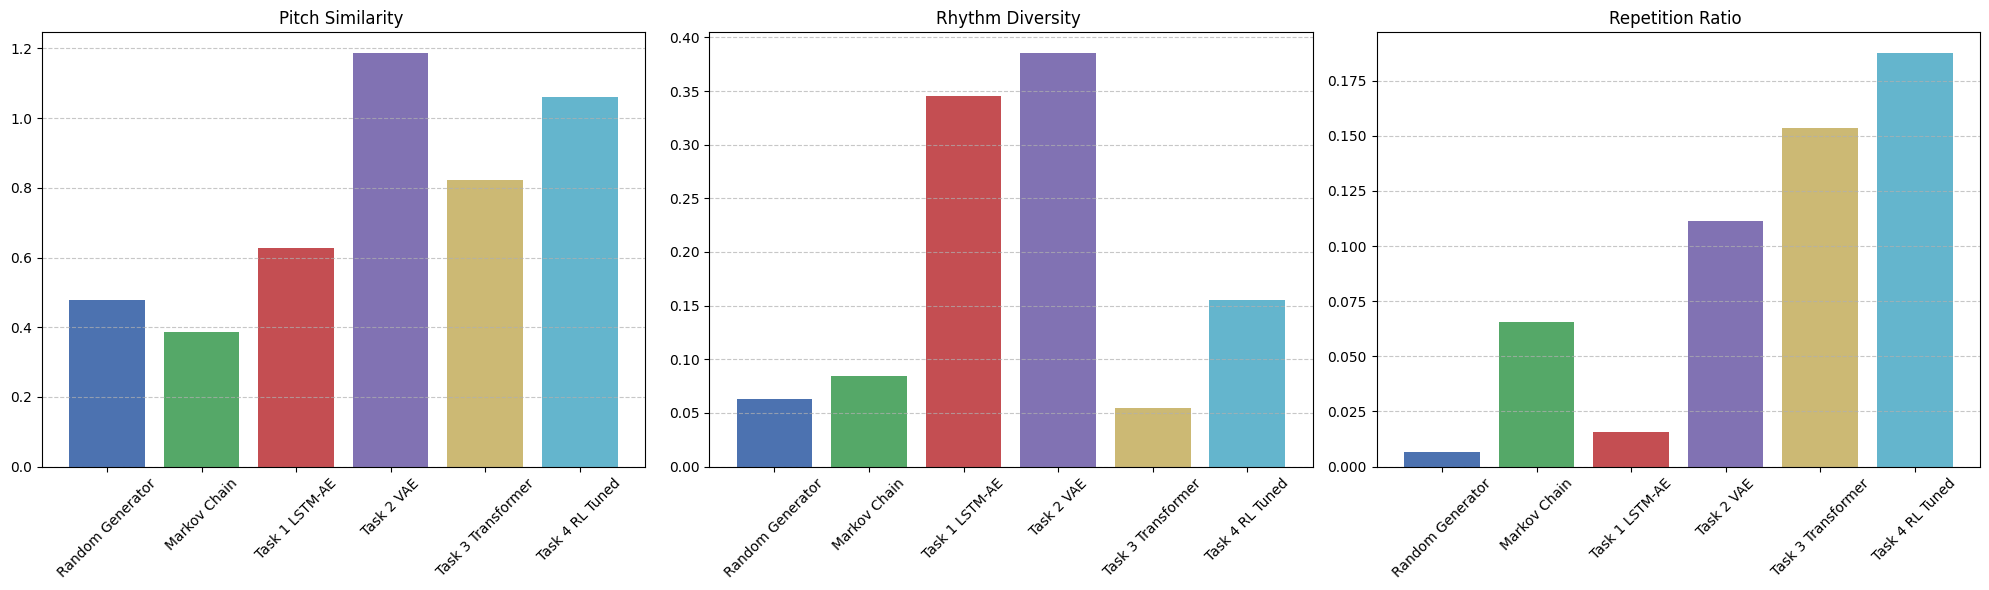

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data including Task 2 values from previous analysis
data = {
    'Model': ['Random Generator', 'Markov Chain', 'Task 1 LSTM-AE', 'Task 2 VAE', 'Task 3 Transformer', 'Task 4 RL Tuned'],
    'PitchSim': [
        ps_random_avg,  # Updated
        ps_markov_avg,  # Updated
        ps1,            # From kernel state
        ps2,            # From kernel state
        0.8216,         # Keep as is
        ps4             # From kernel state
    ],
    'RhythmDiv': [
        rd_random_avg,  # Updated
        rd_markov_avg,  # Updated
        rd1,            # From kernel state
        rd2,            # From kernel state
        0.0550,         # Keep as is
        rd4             # From kernel state
    ],
    'RepRatio': [
        rr_random_avg,  # Updated
        rr_markov_avg,  # Updated
        rr1,            # From kernel state
        rr2,            # From kernel state
        0.1537,         # Keep as is
        rr4             # From kernel state
    ]
}

df_results = pd.DataFrame(data)

# Display the final combined table
print("Combined Model Metrics Comparison")
display(df_results)

# Generate Graphs
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = [('PitchSim', 'Pitch Similarity '), ('RhythmDiv', 'Rhythm Diversity '), ('RepRatio', 'Repetition Ratio ')]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD']

for i, (col, title) in enumerate(metrics):
    axes[i].bar(df_results['Model'], df_results[col], color=colors)
    axes[i].set_title(title)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
